# Overview of Image-Based Two-Phase Flow Simulations

PoreSpy includes several functions for simulation the displacement of one phase by another.  These include `drainage`, `imbibition`, and `invasion`.  The objectives of this tutorial are:

- Give a brief overview of each of the displacement algorithms
- Demonstrate how to define inlets and outlets
- Introduce the concept of "displacement maps", which encode the entire history of the simulation in a single image
- Define the sequence, saturation and capillary pressure maps
- Convert between sequence, saturation, and capillary pressure maps
- Explain the conventions used for dealing with trapped and residual phase in displacement maps
- Plot capillary pressure curves using the results of these simulations

## Setup

As usual, we start by importing the necessary packages, and creating a test image which will be used throughout.  The test image is 2D for visualization purposes, but everything discussed here applies to 3D as well.

In [12]:
import numpy as np
import porespy as ps
import matplotlib.pyplot as plt
ps.visualization.set_mpl_style()

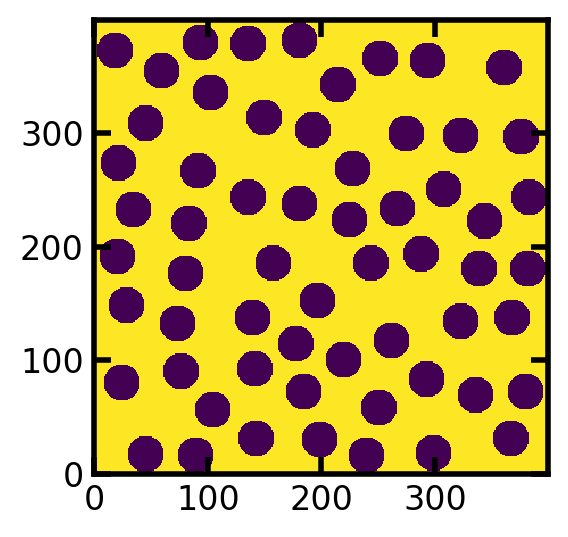

In [13]:
im = ~ps.generators.random_spheres([400, 400], r=15, clearance=10, seed=22)
fig, ax = plt.subplots(figsize=[3, 3])
ax.imshow(im);


## Pressure-Based Drainage

The standard two-phase flow experiment is to apply a fixed pressure to the non-wetting phase and monitor the volume of void space that is invaded.  Repeating this process at progressively higher pressures results in a drainage curve. Using PoreSpy this can be simulated as follows:

First we create a boolean image with `True` values where we would like the invading fluid to enter the domain.  We can do this manually using `numpy`, or use PoreSpy's built-in features:

In [14]:
inlets = np.zeros_like(im)
inlets[0, ...] = True
# Alternatively we could use:
inlets = ps.generators.faces(im.shape, inlet=0)

Next we need to create the capillary pressure transform. This is new to PoreSpy 3+, and it helps to simplify the code by separating the computation of capillary pressure from the act of simulating the displacement. Specifically, it reduces the number of arguments that need to be passed to the various displacement algorithms, reduces the length of the docstring, and simplifies the codebase. PoreSpy includes a function which computes the capillary pressure transform given a variety of arguments. We'll start by just looking at the most basic case of a highly non-wetting invading phase (contact angle `theta=180`), which has a low surface tension (`sigma=0.01` N/m), on an image with 100 um per voxel resolution:

In [15]:
pc = ps.filters.capillary_transform(im=im, sigma=0.01, theta=180, voxel_size=1e-4)

We're now ready to perform the drainage simulation:

In [16]:
drn1 = ps.simulations.drainage(im=im, pc=pc, inlets=inlets)

The function returns a `Results` object which is just a simple `dataclass` like object that has the resultant images attached as attributes.  It can be printed:

In [17]:
print(drn1)

――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Results of ibop generated at Tue Feb 11 23:58:34 2025
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
im_satn                   Array of size (400, 400)
im_seq                    Array of size (400, 400)
im_pc                     Array of size (400, 400)
pc                        Array of size (10,)
snwp                      Array of size (10,)
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――


Here we see 3 images (prepended by `im_`).  These are the saturation map, the sequence map, and the capillary pressure map.  The term "map" has a special meaning, which is the main focus of this tutorial.

### Displacement Maps: Sequence, Pressure, and Saturation Maps

Displacement maps allow the full history of the displacement simulation to be encoded in a single image.  These simply tell us the step number, global saturation, of phase pressure at which each voxel was invaded. Consider the sequence map from the `drn1` simulation we performed above shown below:

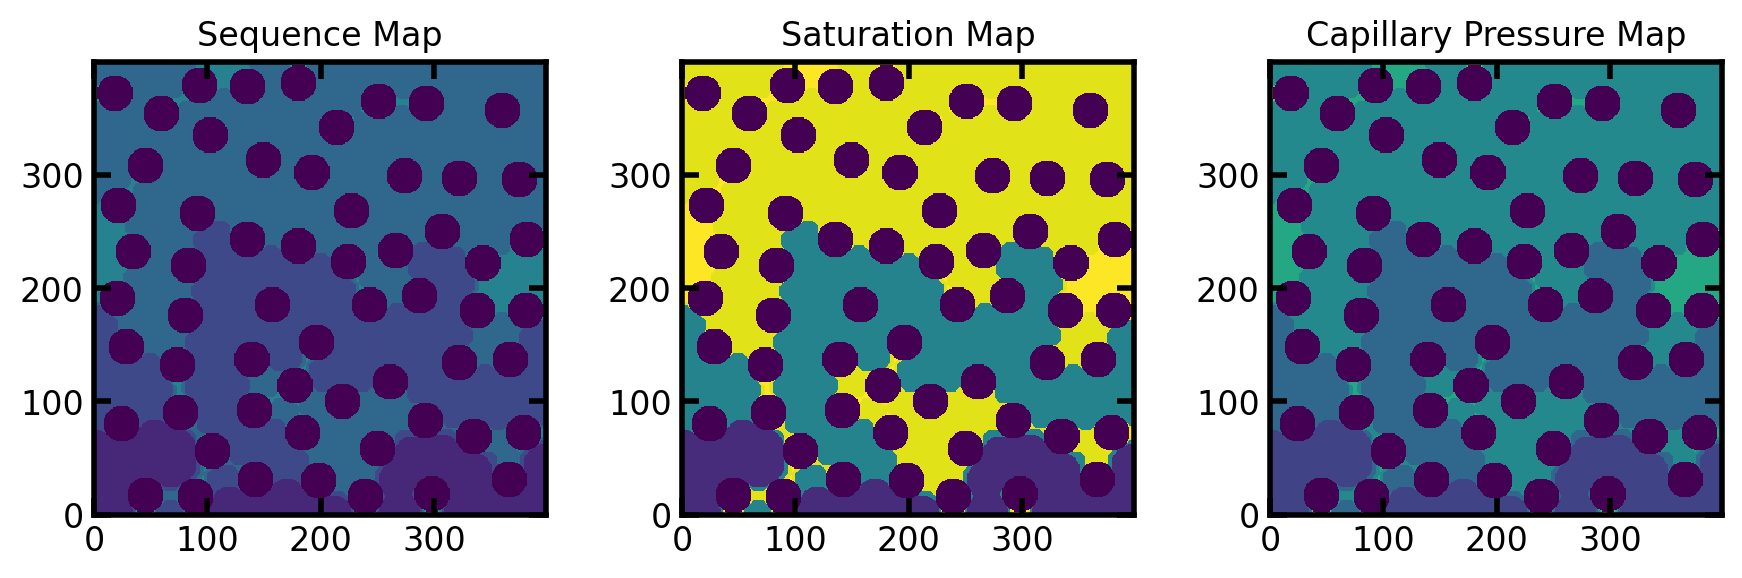

In [18]:
fig, ax = plt.subplots(1, 3, figsize=[9, 3])
ax[0].imshow(drn1.im_seq)
ax[1].imshow(drn1.im_snwp)
ax[2].imshow(drn1.im_pc, vmax=drn1.im_pc.max()/3)
ax[0].set_title("Sequence Map")
ax[1].set_title("Saturation Map")
ax[2].set_title("Capillary Pressure Map");

### Obtaining Fluid Configurations from Displacement Maps

The colors in the above displacement maps corresponds to the step number at which each pixel was invaded.  With this information we can find the fluid configuration at each step as follows:

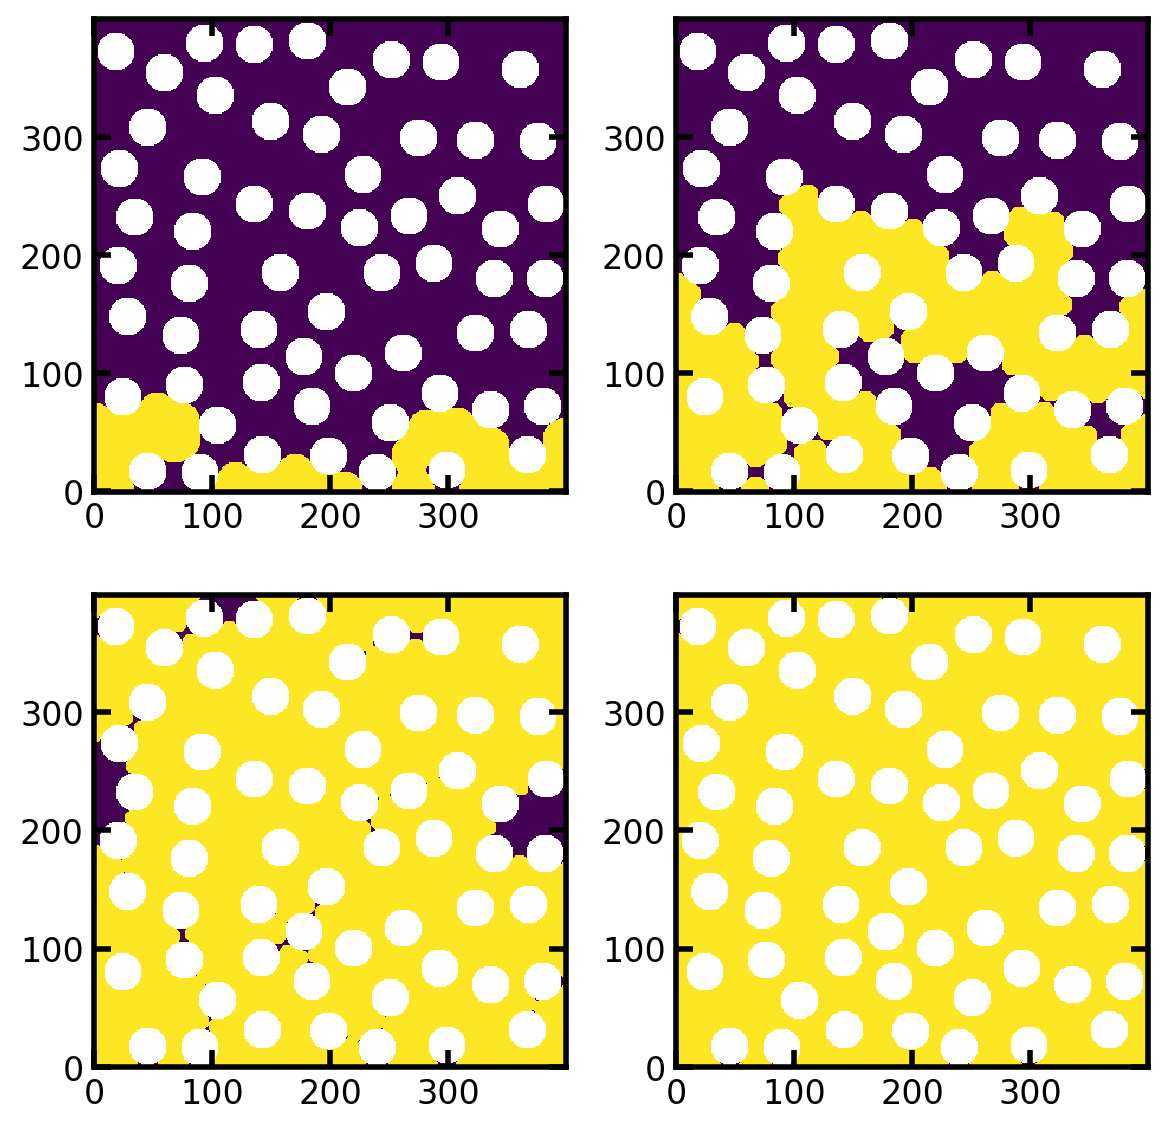

In [19]:
fig, ax = plt.subplots(2, 2, figsize=(6, 6))
ax[0][0].imshow((drn1.im_seq <= 1)/im)
ax[0][1].imshow((drn1.im_seq <= 2)/im)
ax[1][0].imshow((drn1.im_seq <= 3)/im)
ax[1][1].imshow((drn1.im_seq <= 4)/im);

The same sort of images can be produced by applying thresholds to saturation map (`drn1.im_snwp`) and the capillary pressure map (`drn1.im_pc`).

### Generating Capillary Pressure Curves from Displacement Maps

Another useful feature of the displacement maps is that capillary pressure curves can be created from them. This can be accomplished by counting the number of voxels in the capillary pressure map that can be invaded at a given pressure. For instance:

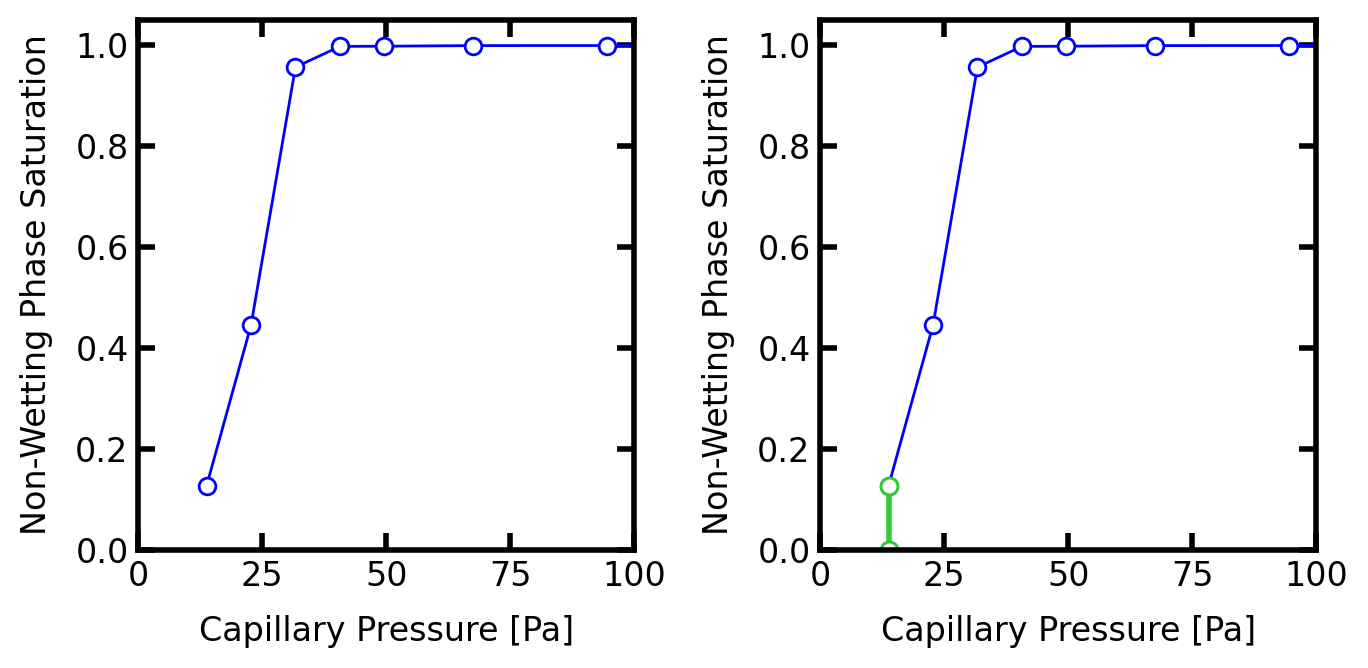

In [20]:
Pc = np.unique(drn1.im_pc[im]).tolist()
satn = []
for p in Pc:
    nwp = (drn1.im_pc <= p)*im
    satn.append(nwp.sum()/im.sum())

fig, ax = plt.subplots(1, 2, figsize=[7, 3.5])
ax[0].plot(Pc, satn, marker='o', markersize=6, linewidth=1, color='blue')
ax[0].set_xlabel('Capillary Pressure [Pa]')
ax[0].set_ylabel('Non-Wetting Phase Saturation')
ax[0].set_xlim([0, 100])
ax[0].set_ylim([0, 1.05])

Pc.insert(0, Pc[0])
satn.insert(0, 0)
ax[1].plot(Pc, satn, marker='o', markersize=6, linewidth=1, color='blue')
ax[1].plot(Pc[:2], satn[:2], marker='o', markersize=6, linewidth=2, color='limegreen')
ax[1].set_xlabel('Capillary Pressure [Pa]')
ax[1].set_ylabel('Non-Wetting Phase Saturation')
ax[1].set_xlim([0, 100])
ax[1].set_ylim([0, 1.05]);

When converting capillary pressure maps to capillary pressure curves the start and stop points of the curves must be considered carefully.  This is true when trapping and residual phases are present, as will be discussed below, but is also necessary when considering the basic case above.  The curve on the left graph starts around `(Pc, satn) = (14, 0.12)`, which occurs because the lowest capillary pressure present in the capillary pressure map is `14 Pa`.  The number of voxels invaded at this pressure represents a saturation of `0.12`. This implies that some residual non-wetting phase was present in the image prior to performing the simulation, but this is not the case.  This can be remedied by adding a point at `satn = 0` and `Pc = 14 Pa`, which is illustrated by the green segment in the right plot.  

PoreSpy includes a function to compute the `(Pc, Snwp)` values of the capillary curve from the capillary map: `porespy.metrics.pc_map_to_pc_curve`. This saves us the trouble having to create the plot as demonstrated above.

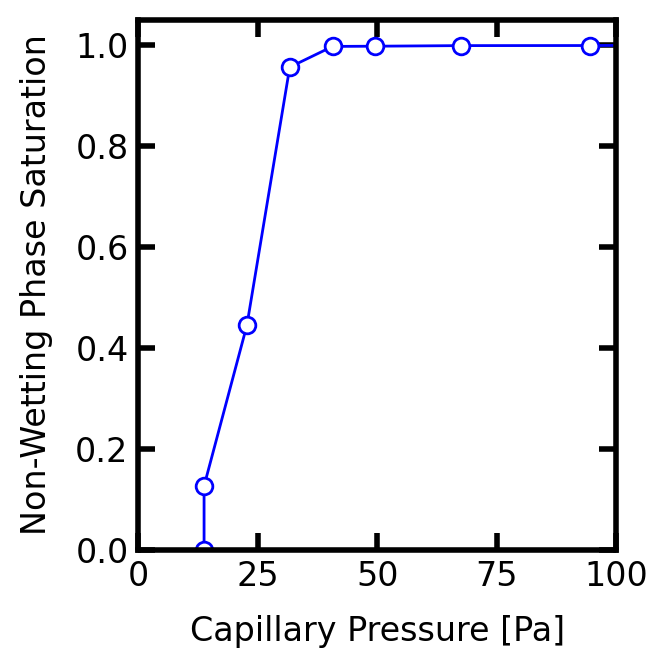

In [21]:
Pc, Snwp = ps.metrics.pc_map_to_pc_curve(im=im, pc=drn1.im_pc, mode='drainage')

fig, ax = plt.subplots(figsize=[3.5, 3.5])
ax.plot(Pc, Snwp, marker='o', markersize=6, linewidth=1, color='blue')
ax.set_xlabel('Capillary Pressure [Pa]')
ax.set_ylabel('Non-Wetting Phase Saturation')
ax.set_xlim([0, 100])
ax.set_ylim([0, 1.05]);

## Incorporating Trapping in Drainage

Trapping occurs when the defending fluid cannot exit from the domain because it becomes surrounded by the invading fluid. The `porespy.simulations.drainage` function can incorporate trapping in the output values. This will be applied automatically if the `outlets` are specified:

In [22]:
outlets = ps.generators.faces(im.shape, outlet=0)
drn2 = ps.simulations.drainage(im=im, pc=pc, inlets=inlets, outlets=outlets)

Plotting the capillary pressure curve as before shows that the final saturation reached by the invading fluid will be less that 1.0, which is occurs because the void space does not become completely filled by the invading fluid:

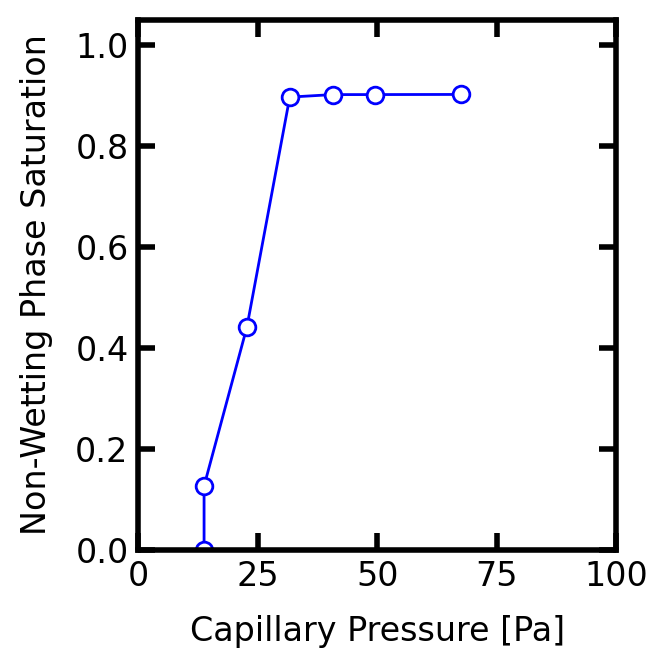

In [23]:
Pc, Snwp = ps.metrics.pc_map_to_pc_curve(im=im, pc=drn2.im_pc, mode='drainage')

fig, ax = plt.subplots(figsize=[3.5, 3.5])
ax.plot(Pc, Snwp, marker='o', markersize=6, linewidth=1, color='blue')
ax.set_xlabel('Capillary Pressure [Pa]')
ax.set_ylabel('Non-Wetting Phase Saturation')
ax.set_xlim([0, 100])
ax.set_ylim([0, 1.05]);

Special care must be taken to denote that certain voxels are trapped in the various displacement maps. In the capillary pressure map a value of `+inf` indicates that those voxels are never invaded, regardless of how much pressure is applied. This can be seen below as the white pixels. This is also practically useful since it means that the saturation for a given capillary pressure can be found using thresholds as demonstrated above. In the saturation and sequence maps, however, things are not quite as straightforward. For the saturation map it is useful if the maximum saturation can be found by looking at the maximum value in the image, which means that `+inf` is not a good option. And the sequence map contains integers, so cannot store the value `+inf`. For both of these cases a value of `-1` is the only viable option, but this makes it more challenging to apply thresholds to the images to obtain fluid configurations. For example to find all pixels which were invaded at step N, we must write `(im_seq <= N) and (im_seq >= 0)`.

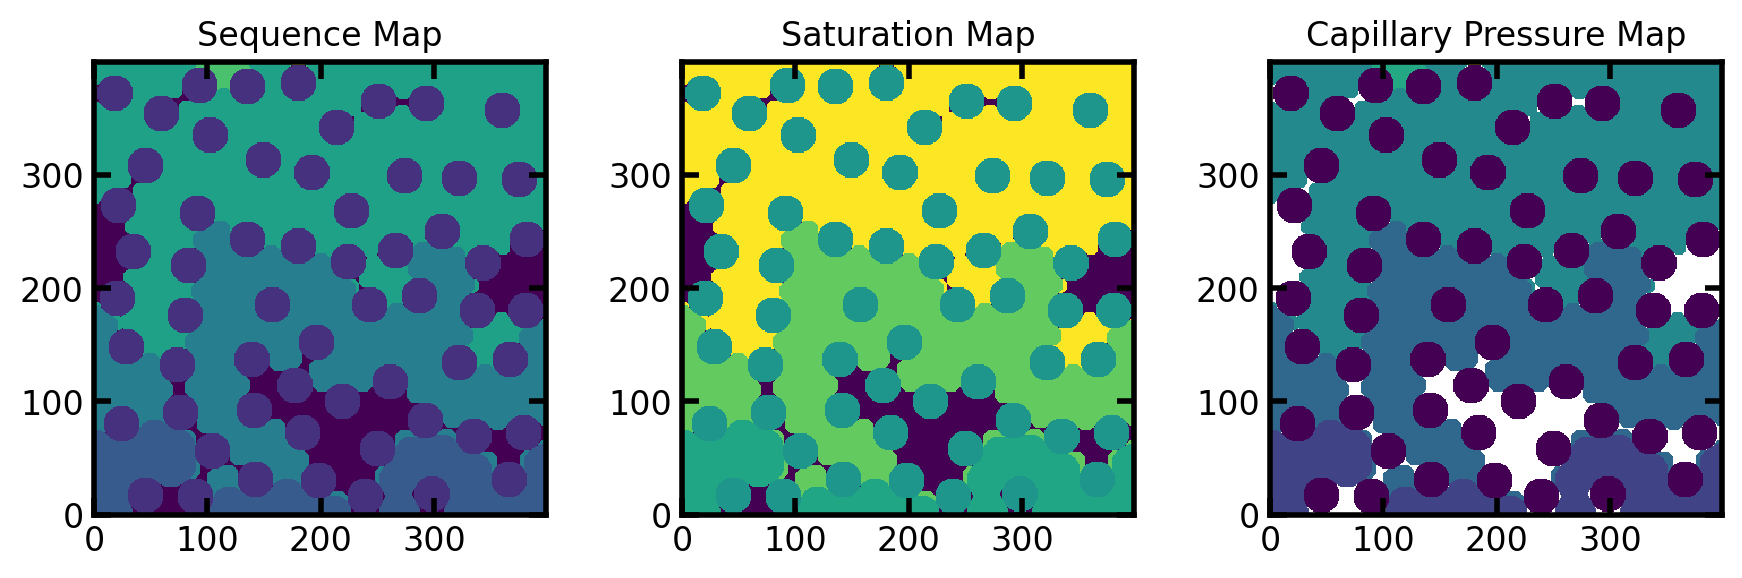

In [25]:
fig, ax = plt.subplots(1, 3, figsize=[9, 3])
ax[0].imshow(drn2.im_seq)
ax[1].imshow(drn2.im_snwp)
ax[2].imshow(drn2.im_pc)
ax[0].set_title("Sequence Map")
ax[1].set_title("Saturation Map")
ax[2].set_title("Capillary Pressure Map");